## Libraries

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import path
import re
import pickle
import joblib
import shap
from pathlib import Path
import os

from sklearn.model_selection import train_test_split, cross_validate, StratifiedKFold, GridSearchCV
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler, OneHotEncoder
from sklearn.feature_selection import SelectKBest, chi2, f_classif

from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier
from sklearn.ensemble import AdaBoostClassifier, GradientBoostingClassifier, RandomForestClassifier

from sklearn.compose import ColumnTransformer
from sklearn.metrics import accuracy_score, recall_score, confusion_matrix, f1_score, balanced_accuracy_score, classification_report, fbeta_score, make_scorer, ConfusionMatrixDisplay
from sklearn.inspection import PartialDependenceDisplay
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.pipeline import Pipeline
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE, ADASYN
from mrmr import mrmr_classif

import warnings

warnings.simplefilter(action = 'ignore', category = FutureWarning)
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', None)

## Load & view dataset

In [2]:
base_path = Path.cwd()
data_dir = base_path / "data"
data_dir.mkdir(exist_ok=True)

In [3]:
data_path = os.path.join("data", "healthcare-dataset-stroke-data.csv")
df = pd.read_csv(data_path)

display(df)
df['stroke'].value_counts()

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1
...,...,...,...,...,...,...,...,...,...,...,...,...
5105,18234,Female,80.0,1,0,Yes,Private,Urban,83.75,NaN,never smoked,0
5106,44873,Female,81.0,0,0,Yes,Self-employed,Urban,125.20,40.0,never smoked,0
5107,19723,Female,35.0,0,0,Yes,Self-employed,Rural,82.99,30.6,never smoked,0
5108,37544,Male,51.0,0,0,Yes,Private,Rural,166.29,25.6,formerly smoked,0


stroke
0    4861
1     249
Name: count, dtype: int64

First observation: Highly imbalanced set

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 5110 non-null   int64  
 1   gender             5110 non-null   object 
 2   age                5110 non-null   float64
 3   hypertension       5110 non-null   int64  
 4   heart_disease      5110 non-null   int64  
 5   ever_married       5110 non-null   object 
 6   work_type          5110 non-null   object 
 7   Residence_type     5110 non-null   object 
 8   avg_glucose_level  5110 non-null   float64
 9   bmi                4909 non-null   float64
 10  smoking_status     5110 non-null   object 
 11  stroke             5110 non-null   int64  
dtypes: float64(3), int64(4), object(5)
memory usage: 479.2+ KB


In [5]:
df.describe()

,id,age,hypertension,heart_disease,avg_glucose_level,bmi,stroke
count,5110.000000,5110.000000,5110.000000,5110.000000,5110.000000,4909.000000,5110.000000
mean,36517.829354,43.226614,0.097456,0.054012,106.147677,28.893237,0.048728
std,21161.721625,22.612647,0.296607,0.226063,45.283560,7.854067,0.215320
min,67.000000,0.080000,0.000000,0.000000,55.120000,10.300000,0.000000
25%,17741.250000,25.000000,0.000000,0.000000,77.245000,23.500000,0.000000
50%,36932.000000,45.000000,0.000000,0.000000,91.885000,28.100000,0.000000
75%,54682.000000,61.000000,0.000000,0.000000,114.090000,33.100000,0.000000
max,72940.000000,82.000000,1.000000,1.000000,271.740000,97.600000,1.000000


## Dataset preprocessing

Lets use some of the dataset (4000/5000 rows) to train & test the model on and leave some (1000 untouched-rows) to simulate new data where we will use the trained model on for our goals 

(also that file can be used in the streamlit app to simulate getting results on new & unseen data)

In [6]:
df_modeling = df.sample(n=4000, random_state=0)
df_production = df.drop(df_modeling.index)

prod_file_save_path = os.path.join("data", "real-data-simulation-with-stroke-column.csv")
df_production.to_csv(prod_file_save_path, index=False) # save the remaining data to a separate file we will use later in the analysis here
print(f"Production data saved to: {prod_file_save_path}")

df_production2 = df_production.drop(columns = 'stroke')
prod_file_save_path = os.path.join("data", "real-data-simulation-without-stroke-column.csv")
df_production2.to_csv(prod_file_save_path, index=False) # save the remaining data to a separate file we will use later in our streamlit app as an "import" file
print(f"Production data saved to: {prod_file_save_path}")

df_modeling_ids = df_modeling['id']
df_modeling.drop(columns='id', inplace=True) # id column is meaningless, so we drop

Production data saved to: data\real-data-simulation-with-stroke-column.csv
Production data saved to: data\real-data-simulation-without-stroke-column.csv


In [7]:
numeric_features = ['age', 'avg_glucose_level','bmi']
categorical_features = ['hypertension', 'heart_disease', 'gender', 'ever_married', 'work_type', 'Residence_type', 'smoking_status']

X = df_modeling[numeric_features + categorical_features]
y = df_modeling['stroke']

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=0, test_size=0.2, stratify=y)

# Impute and scale the numeric and categorical columns before we one-hot encode and run models:
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', 'passthrough')])
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='missing')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)])

## Run models on the processed data and see which performs best

The models will run on an imputed, scaled, adasyn'ed modeling dataset

In [8]:
models = [
    RandomForestClassifier(random_state=0),
    AdaBoostClassifier(random_state=0),
    GaussianNB(),
    SVC(random_state=0, class_weight="balanced"),
    LGBMClassifier(random_state=0),
    XGBClassifier(random_state=0),
    ]

for model in models:
    pipe = ImbPipeline(
            steps=[
                ('preprocessor', preprocessor),
                ('imputer', SimpleImputer()),
                ('scaler', StandardScaler()),
                ('smote' , ADASYN(random_state=0)), # Since our data is quite messy, I will use ADASYN which focuses on creating data in the "hard to learn" areas where the classes overlap and not SMOTE
                ('selectk', SelectKBest(score_func=f_classif, k='all')),
                ('model', model)
            ])

    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)
    print(f'Model: {model}')
    print(classification_report(y_test, y_pred))

Model: RandomForestClassifier(random_state=0)
              precision    recall  f1-score   support

           0       0.95      0.96      0.96       762
           1       0.09      0.08      0.08        38

    accuracy                           0.92       800
   macro avg       0.52      0.52      0.52       800
weighted avg       0.91      0.92      0.92       800

Model: AdaBoostClassifier(random_state=0)
              precision    recall  f1-score   support

           0       0.98      0.78      0.87       762
           1       0.13      0.63      0.21        38

    accuracy                           0.78       800
   macro avg       0.55      0.71      0.54       800
weighted avg       0.94      0.78      0.84       800

Model: GaussianNB()
              precision    recall  f1-score   support

           0       0.99      0.34      0.50       762
           1       0.07      0.95      0.12        38

    accuracy                           0.37       800
   macro avg       0

### Since Adaboost is the best-performing model all around, we will proceed to tune its hyperparameters

Fitting 5 folds for each of 12 candidates, totalling 60 fits
Best AdaBoost Params (F2 Optimized):
{'model__learning_rate': 0.1, 'model__n_estimators': 100, 'preprocessor__num__imputer__strategy': 'median', 'preprocessor__num__scaler': StandardScaler()}

              precision    recall  f1-score   support

           0       0.98      0.69      0.81       762
           1       0.11      0.79      0.20        38

    accuracy                           0.69       800
   macro avg       0.55      0.74      0.50       800
weighted avg       0.94      0.69      0.78       800



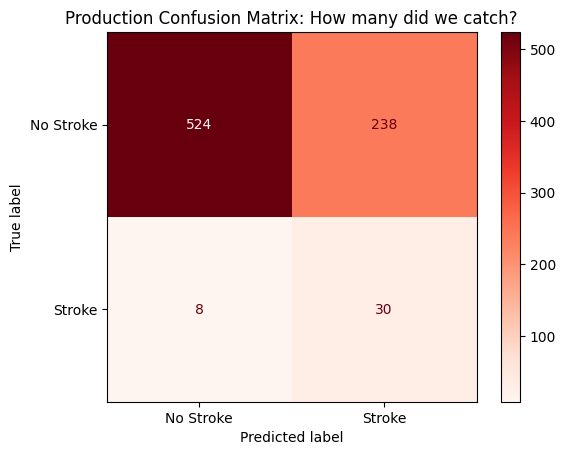

In [9]:
pipe_ada = ImbPipeline(steps=[
    ('preprocessor', preprocessor),
    ('smote', ADASYN(random_state=0)),
    ('selectk', SelectKBest(score_func=f_classif, k='all')),
    ('model', AdaBoostClassifier(random_state=0))])

params_ada = {
    "preprocessor__num__scaler": [StandardScaler()], # MinMaxScaler(), RobustScaler()],
    "preprocessor__num__imputer__strategy": ["mean", "median"],
    # "selectk__k": [16, 17, 18, 19, 20],
    "model__n_estimators": [50, 100, 200],
    "model__learning_rate": [0.1, 1.0],
}

f2_scorer = make_scorer(fbeta_score, beta=2, pos_label=1) # Prioritizing Recall

grid_ada = GridSearchCV(
    pipe_ada, 
    param_grid=params_ada, 
    cv=5, 
    scoring=f2_scorer, # scoring='recall'
    verbose=True
)

grid_ada.fit(X_train, y_train)

print(f"Best AdaBoost Params (F2 Optimized):\n{grid_ada.best_params_}\n")
y_pred_ada = grid_ada.best_estimator_.predict(X_test)
print(classification_report(y_test, y_pred_ada))

# Confusion Matrix Viz
cm = confusion_matrix(y_test, y_pred_ada)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Stroke', 'Stroke'])
disp.plot(cmap='Reds')
plt.title("Production Confusion Matrix: How many did we catch?")
plt.show()

The final configuration of this model was chosen based on the following findings:

Scaling Strategy: While MinMaxScaler() produced higher overall Accuracy and Precision, StandardScaler() was selected because it consistently yielded a significantly higher Recall. In a stroke prediction context, preserving the variance of outliers (like extreme glucose or BMI levels) is vital for catching high-risk cases.

Feature Count (k): I performed a grid search testing k values from 16 to 20. Although models with k=16 were more compact, they resulted in a ~2% performance drop across metrics like Precision and F1-score without improving Recall. Consequently, I have retained all 20 features to maintain maximum model robustness.

Optimization Metric: Although pure recall (scoring='recall') was tested as a scoring metric, the F2​ score was ultimately chosen. It provides the necessary heavy bias toward Recall BUT ALSO ensures the model maintains enough Precision to be useful in a simulated production environment.

### Cross Validation on the same model

In [21]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=0)

metrics = {
    'f1_macro': 'f1_macro',
    'recall': 'recall',
    'precision': 'precision',
    'f2': f2_scorer  # The one we defined previously
}

cv_results = cross_validate(
    grid_ada.best_estimator_, 
    X_train, 
    y_train, 
    cv=skf, 
    scoring=metrics, 
    return_train_score=False
)

print(f"CROSS-VALIDATION RESULTS (5 FOLDS)")

f2_scores = cv_results['test_f2']
print("=" * 62)
for i, score in enumerate(f2_scores):
    print(f"Fold {i+1} - F2 Score: {score:.4f} | Recall: {cv_results['test_recall'][i]:.4f} | Precision: {cv_results['test_precision'][i]:.4f}")
print("=" * 62)
print(f"Mean F2 Score:    {np.mean(cv_results['test_f2']):.4f}")
print(f"Mean Recall:      {np.mean(cv_results['test_recall']):.4f} (Avg Strokes Caught)")
print(f"Mean Precision:   {np.mean(cv_results['test_precision']):.4f}")
print(f"Recall Std Dev:   {np.std(cv_results['test_recall']):.4f}")


CROSS-VALIDATION RESULTS (5 FOLDS)
Fold 1 - F2 Score: 0.3382 | Recall: 0.7667 | Precision: 0.1045
Fold 2 - F2 Score: 0.3944 | Recall: 0.9333 | Precision: 0.1191
Fold 3 - F2 Score: 0.3560 | Recall: 0.7667 | Precision: 0.1133
Fold 4 - F2 Score: 0.4127 | Recall: 0.8667 | Precision: 0.1333
Fold 5 - F2 Score: 0.3641 | Recall: 0.8667 | Precision: 0.1097
Mean F2 Score:    0.3731
Mean Recall:      0.8400 (Avg Strokes Caught)
Mean Precision:   0.1160
Recall Std Dev:   0.0646


The Precision is extremely stable (around 11%). 
This means the "cost" to the hospital (false alarms) is predictable, even if the "benefit" (caught strokes) fluctuates slightly.

F2 is consistent and in a healthy range (0.34−0.41). 
This confirms that the F2​ scorer is successfully keeping the model focused on the minority class despite the data imbalance.

Observation on Fold 2/Fold 3 fluctuation:

Since the stroke class is so small (only about 3-5% of the data), moving just 2 or 3 patients from the training set to the testing set can swing the Recall percentage significantly. This is why I chose ADASYN over SMOTE. 
It tries to "pad" those difficult areas so the model doesn't get blindsided by a slightly different test set.

## Feature Importance

### Gini importance

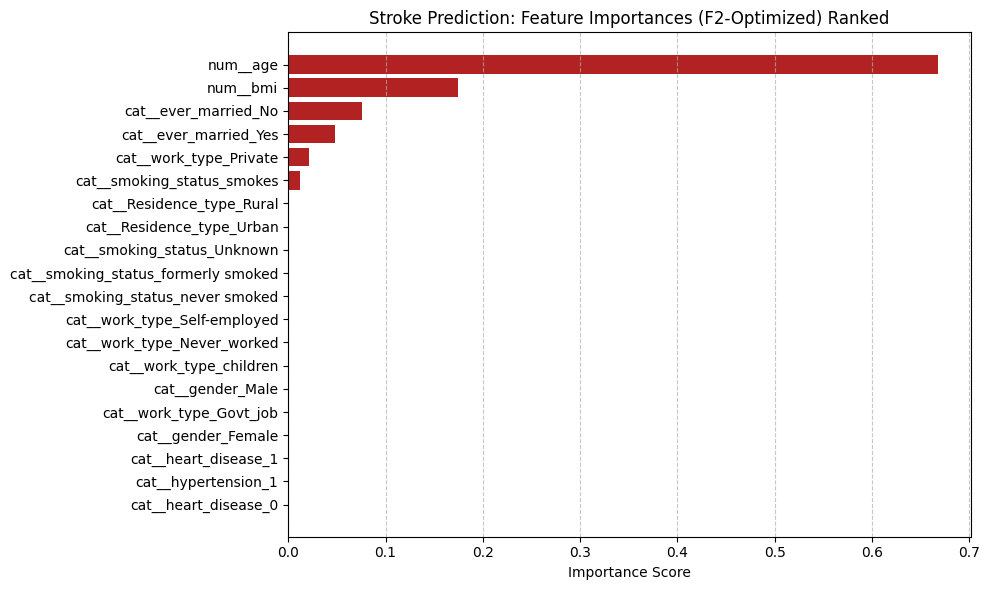

In [11]:
# Now we will fetch the feature names from the preprocessor step and also find their importances:
feature_names = grid_ada.best_estimator_.named_steps['preprocessor'].get_feature_names_out()
importances = grid_ada.best_estimator_.named_steps['model'].feature_importances_

indices = np.argsort(importances)[-20:] 
plt.figure(figsize=(10, 6))
plt.title('Stroke Prediction: Feature Importances (F2-Optimized) Ranked')
plt.barh(range(len(indices)), importances[indices], color='firebrick', align='center')
plt.yticks(range(len(indices)), [feature_names[i] for i in indices])
plt.xlabel('Importance Score')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

So out of our 20 columns, 14 columns' importance is zero. 

But this does not mean they are useless, though they could be made redundant by another feature.

Top contributors are age, bmi and married status

### SHAP values & comparison

PermutationExplainer explainer: 801it [02:22,  5.44it/s]                         


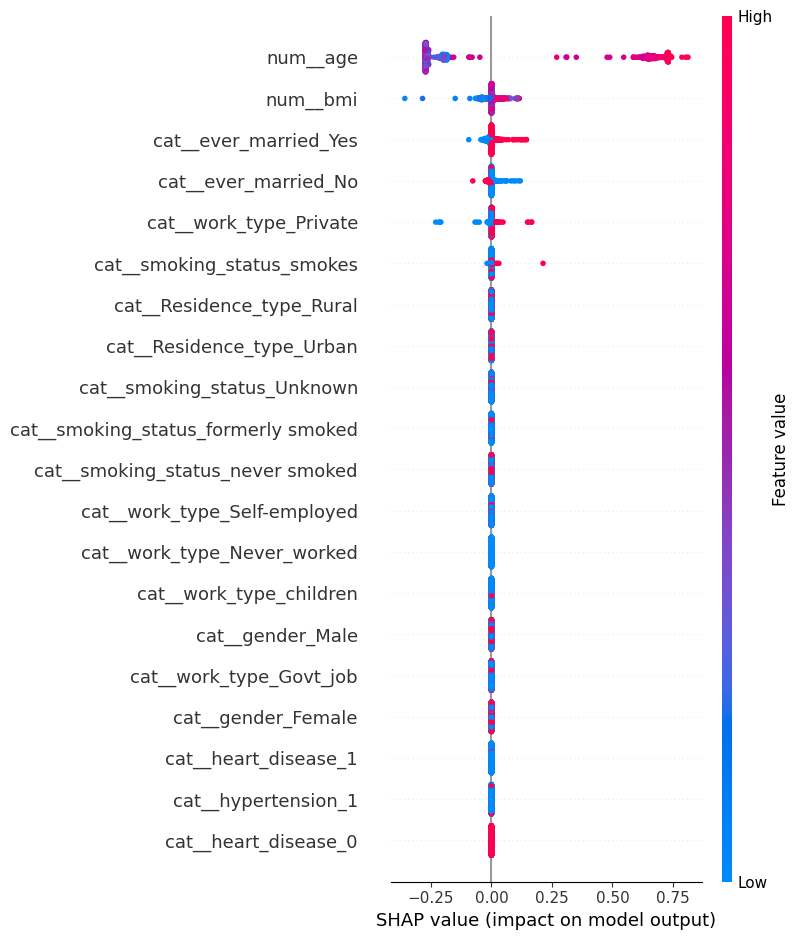

In [ ]:
# Transform the raw X_test into the numeric format the model expects
X_test_transformed = grid_ada.best_estimator_.named_steps['preprocessor'].transform(X_test)
feature_names = grid_ada.best_estimator_.named_steps['preprocessor'].get_feature_names_out()
# I use the 'model' step and provide the transformed data as a reference
model_step = grid_ada.best_estimator_.named_steps['model']
# I could use shap.sample to speed things up if the dataset is large but with 800 rows, it should be fine
explainer = shap.Explainer(model_step.predict, X_test_transformed, feature_names=feature_names)

shap_values = explainer(X_test_transformed)

plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_test_transformed, feature_names=feature_names)

Here we see how each feature pushed a patient's prediction toward either "Healthy" (left of the center line) or "Stroke Risk" (right of the center line).

Explaining the Top 5:

**Age:**
As we suspected, 'age' is the most influential feature.
    The long trail of red dots (high age) extending far to the right indicates that as age increases, the probability of a stroke prediction increases significantly. While the "Safe Zone" of the cluster of blue/purple dots on the left shows that younger age is the strongest predictor for "No Stroke".
    One thing I notice is about the large empty space in the row between the neutral center and the high-impact pink dots. This suggests there is a specific "threshold" (likely around 50-60 years old) where the risk isn't just higher, it skyrockets.

**BMI:**
Interestingly, 'bmi' shows a concentrated cluster of blue dots on the left.
    This suggests that in this specific dataset, having a lower BMI is a very strong indicator of health (low risk), while higher BMI (red dots) has a more distributed, less aggressive impact on the positive side compared to age.

**ever_married_No/Yes:** 
    For ever_married_Yes, the pink dots (representing "True", meaning the person is married) are clustered to the right of the center line, indicating that being married increases the stroke risk probability. Same can be observed for ever_married_No, though the dot colours are inversed (the blue dots represent "False," meaning the person is married).
    
**work_type_Private:**
    There is a small but visible cluster of red dots on the right, suggesting that "Private" sector work correlates with a slightly higher risk in this model compared to other work types.

**smoking_status_smokes:**
    We see a distinct trail of red dots to the right. This confirms that being a smoker increases the model's stroke risk score.

**Observation**

Clinically, marital status is unlikely to be a direct biological cause of stroke. Instead, the model is leveraging these features as a "proxy" for Age. Since older patients are statistically more likely to have been married at some point, the model uses these categorical markers to strengthen its "Age-First" logic.

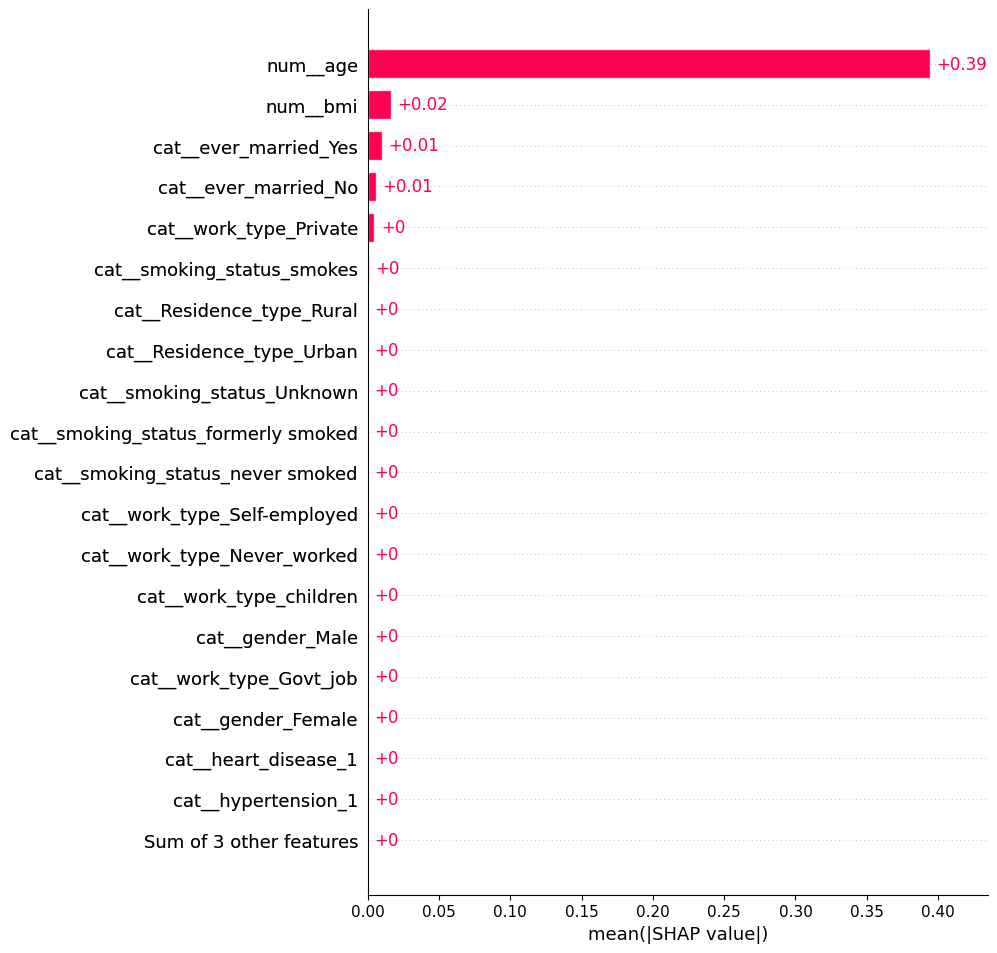

In [13]:
shap.plots.bar(shap_values, max_display=20)

SHAP & Gini Verdict: 

While being two fundamentally different mathematical approaches, Gini Importance and SHAP Values agree on the Top 5 columns.
This means the model is highly stable and reliable and isn't just 'guessing' based on noise, it has found a clear signal.

## MRMR to audit the Gini and SHAP results

In [14]:
X_train_pre = grid_ada.best_estimator_.named_steps['preprocessor'].transform(X_train)
all_feature_names = grid_ada.best_estimator_.named_steps['preprocessor'].get_feature_names_out()

#Reset the index of X_train and y_train
X_train_df = pd.DataFrame(X_train_pre, columns=all_feature_names).reset_index(drop=True)
y_train_reset = y_train.reset_index(drop=True)

mrmr_ranking = mrmr_classif(X=X_train_df, y=y_train_reset, K=20)

print("mRMR Relevance vs Redundancy:")
for i, feat in enumerate(mrmr_ranking, 1):
    print(f"{i}. {feat}")

100%|██████████| 20/20 [00:06<00:00,  2.92it/s]

mRMR Relevance vs Redundancy:
1. num__age
2. cat__heart_disease_1
3. num__avg_glucose_level
4. cat__hypertension_0
5. cat__heart_disease_0
6. cat__ever_married_No
7. cat__hypertension_1
8. cat__ever_married_Yes
9. cat__smoking_status_formerly smoked
10. cat__work_type_children
11. cat__smoking_status_Unknown
12. cat__work_type_Self-employed
13. num__bmi
14. cat__work_type_Never_worked
15. cat__smoking_status_smokes
16. cat__work_type_Govt_job
17. cat__Residence_type_Rural
18. cat__work_type_Private
19. cat__gender_Female
20. cat__Residence_type_Urban


This mRMR ranking explains exactly why the model’s performance crashed when I tried to cut features based only on Gini Importance or SHAP.
In Gini, Heart Disease, Glucose, and Hypertension were at the very bottom (near zero). In mRMR, they are at the top. So they provide neccessary context to the model's decision and are highly relevant.

## Save the model in a pkl file and finish the analysis

In [15]:
model_folder = "model"
if not os.path.exists(model_folder):
    os.makedirs(model_folder)

model_filename = os.path.join(model_folder, "adaboost_stroke_prediction_4k_trained_model_f2.pkl")
joblib.dump(grid_ada.best_estimator_, model_filename)

print(f"Model saved to: {model_filename}")

Model saved to: model\adaboost_stroke_prediction_4k_trained_model_f2.pkl


## Now let's run on the 1k-rows production dataset (new data simulation)

FINAL SIMULATED PRODUCTION RESULTS
              precision    recall  f1-score   support

           0       0.99      0.69      0.81      1049
           1       0.14      0.87      0.24        61

    accuracy                           0.70      1110
   macro avg       0.56      0.78      0.53      1110
weighted avg       0.94      0.70      0.78      1110



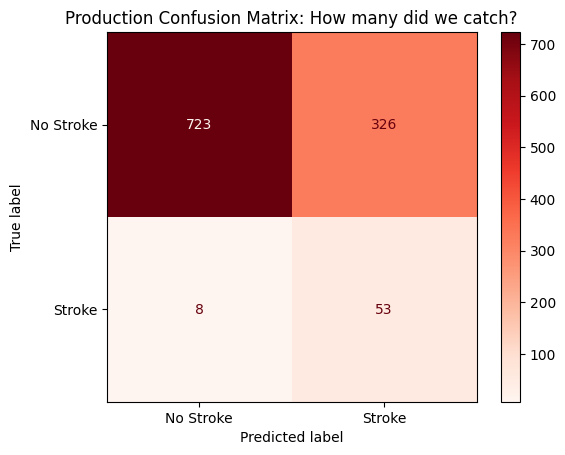

In [16]:
X_prod = df_production[numeric_features + categorical_features]
y_prod = df_production['stroke']

# We predict using the best model from the grid search
y_prod_pred = grid_ada.best_estimator_.predict(X_prod)

print("FINAL SIMULATED PRODUCTION RESULTS")
print(classification_report(y_prod, y_prod_pred))

# Confusion Matrix Viz
cm = confusion_matrix(y_prod, y_prod_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Stroke', 'Stroke'])
disp.plot(cmap='Reds')
plt.title("Production Confusion Matrix: How many did we catch?")
plt.show()

A (53 / 61, 87%) Recall on totally unseen "production" data is even better than our cross-validation mean.
This suggests the model generalizes very well and we are catching nearly 9 out of 10 stroke cases.

So for every person we correctly identify as having a stroke risk, we are also flagging about 6 people who are actually safe. In a hospital setting, this is generally considered an acceptable "noise" level for a life-saving screening, as the cost of a follow-up test is much lower than the cost of a missed stroke.

Final Verdict:

The real-data results (87% recall, 15% precision) are actually stronger than the X_test results (84% recall, 12% precision). 
This means the model isn't overfitted to the training set and might even be performing better as it sees a slightly larger sample.

# Finally, I will fully train the model on the full dataset (modeling+production) and save it.

Total dataset shape: (5110, 12)
FINAL FULL DATASET RESULTS
              precision    recall  f1-score   support

           0       0.99      0.66      0.79      4861
           1       0.12      0.88      0.21       249

    accuracy                           0.67      5110
   macro avg       0.55      0.77      0.50      5110
weighted avg       0.95      0.67      0.77      5110



<Figure size 800x600 with 0 Axes>

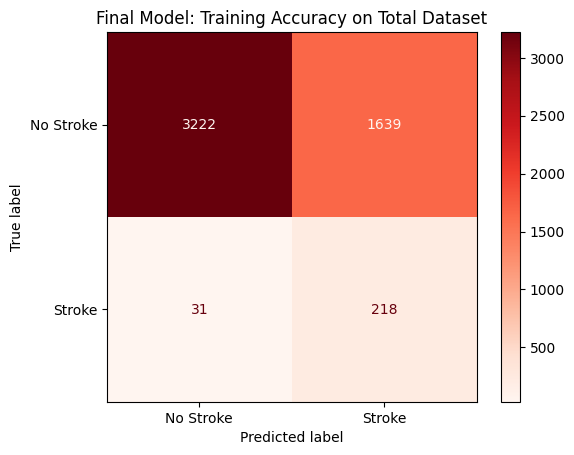

In [ ]:
total_df = pd.concat([df_modeling, df_production], axis=0).reset_index(drop=True)
print(f"Total dataset shape: {total_df.shape}")

X_total = total_df[numeric_features + categorical_features]
y_total = total_df['stroke']

fully_trained_model = grid_ada.best_estimator_
fully_trained_model.fit(X_total, y_total)

y_total_df_pred = fully_trained_model.predict(X_total)

print("FINAL FULL DATASET RESULTS")
print(classification_report(y_total, y_total_df_pred))

cm = confusion_matrix(y_total, y_total_df_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Stroke', 'Stroke'])
plt.figure(figsize=(8, 6))
disp.plot(cmap='Reds')
plt.title("Final Model: Training Accuracy on Total Dataset")
plt.grid(False)
plt.show()

In [18]:
model_folder = "model"
if not os.path.exists(model_folder):
    os.makedirs(model_folder)

model_filename = os.path.join(model_folder, "adaboost_stroke_prediction_5k_trained_model_f2.pkl")
joblib.dump(grid_ada.best_estimator_, model_filename)

print(f"Model saved to: {model_filename}")

Model saved to: model\adaboost_stroke_prediction_5k_trained_model_f2.pkl
